<div style="
    font-family: Arial, sans-serif;
    text-align: center;
    color: #0095DA;
    font-size: 28px;
    font-weight: bold;
">
..................................... Car Insurance Data Mining Project .....................................
</div>

<div style="
    font-family: Arial, sans-serif;
    text-align: left;
    color: #FF4F00;
    font-size: 24px;
    font-weight: bold;
">
1. Loading the Data and Removing the Identifier Column
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_raw = pd.read_csv("Car_Insurance_Claim.csv")

print("Initial data shape:", df_raw.shape)
df_raw.head()

Initial data shape: (10000, 19)


,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,65+,female,majority,0-9y,high school,upper class,0.629027,1,after 2015,0,1,10238,12000.0,sedan,0,0,0,0
1,750365,16-25,male,majority,0-9y,none,poverty,0.357757,0,before 2015,0,0,10238,16000.0,sedan,0,0,0,1
2,199901,16-25,female,majority,0-9y,high school,working class,0.493146,1,before 2015,0,0,10238,11000.0,sedan,0,0,0,0
3,478866,16-25,male,majority,0-9y,university,working class,0.206013,1,before 2015,0,1,32765,11000.0,sedan,0,0,0,0
4,731664,26-39,male,majority,10-19y,none,working class,0.388366,1,before 2015,0,0,32765,12000.0,sedan,2,0,1,1


In [3]:
df = df_raw.copy()
df = df.drop(columns=["ID"])

print("Data shape after removing ID:", df.shape)
df.head()

Data shape after removing ID: (10000, 18)


,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,65+,female,majority,0-9y,high school,upper class,0.629027,1,after 2015,0,1,10238,12000.0,sedan,0,0,0,0
1,16-25,male,majority,0-9y,none,poverty,0.357757,0,before 2015,0,0,10238,16000.0,sedan,0,0,0,1
2,16-25,female,majority,0-9y,high school,working class,0.493146,1,before 2015,0,0,10238,11000.0,sedan,0,0,0,0
3,16-25,male,majority,0-9y,university,working class,0.206013,1,before 2015,0,1,32765,11000.0,sedan,0,0,0,0
4,26-39,male,majority,10-19y,none,working class,0.388366,1,before 2015,0,0,32765,12000.0,sedan,2,0,1,1


<div style="
    text-align: left;
    font-family: Arial, sans-serif;
    font-size: 16px;
    line-height: 1.8;
    color: #222222;
">

<p style="text-align: left;">
The dataset was loaded into the notebook and its initial structure was reviewed. It contains 10,000 rows and 19 columns. The <code>ID</code> column is only a record identifier and does not provide useful information for analysis or modeling, so it was removed.
</p>

</div>

<div style="
    font-family: Arial, sans-serif;
    text-align: left;
    color: #FF4F00;
    font-size: 24px;
    font-weight: bold;
">
2. Initial Data Exploration
</div>

In [4]:
print("Number of rows and columns:", df.shape)

df.head()

Number of rows and columns: (10000, 18)


,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,65+,female,majority,0-9y,high school,upper class,0.629027,1,after 2015,0,1,10238,12000.0,sedan,0,0,0,0
1,16-25,male,majority,0-9y,none,poverty,0.357757,0,before 2015,0,0,10238,16000.0,sedan,0,0,0,1
2,16-25,female,majority,0-9y,high school,working class,0.493146,1,before 2015,0,0,10238,11000.0,sedan,0,0,0,0
3,16-25,male,majority,0-9y,university,working class,0.206013,1,before 2015,0,1,32765,11000.0,sedan,0,0,0,0
4,26-39,male,majority,10-19y,none,working class,0.388366,1,before 2015,0,0,32765,12000.0,sedan,2,0,1,1


In [5]:
df.dtypes

AGE                        str
GENDER                     str
RACE                       str
DRIVING_EXPERIENCE         str
EDUCATION                  str
INCOME                     str
CREDIT_SCORE           float64
VEHICLE_OWNERSHIP        int64
VEHICLE_YEAR               str
MARRIED                  int64
CHILDREN                 int64
POSTAL_CODE              int64
ANNUAL_MILEAGE         float64
VEHICLE_TYPE               str
SPEEDING_VIOLATIONS      int64
DUIS                     int64
PAST_ACCIDENTS           int64
OUTCOME                  int64
dtype: object

In [6]:
summary_table = pd.DataFrame({
    "data_type": df.dtypes,
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().sum() / len(df) * 100).round(2),
    "unique_count": df.nunique()
})

summary_table

,data_type,missing_count,missing_percent,unique_count
AGE,str,0,0.00,4
GENDER,str,0,0.00,2
RACE,str,0,0.00,2
DRIVING_EXPERIENCE,str,0,0.00,4
EDUCATION,str,0,0.00,3
INCOME,str,0,0.00,4
CREDIT_SCORE,float64,982,9.82,9018
VEHICLE_OWNERSHIP,int64,0,0.00,2
VEHICLE_YEAR,str,0,0.00,2
MARRIED,int64,0,0.00,2


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CREDIT_SCORE,9018.0,0.515813,0.137688,0.053358,0.417191,0.525033,0.618312,0.960819
VEHICLE_OWNERSHIP,10000.0,0.697000,0.459578,0.000000,0.000000,1.000000,1.000000,1.000000
MARRIED,10000.0,0.498200,0.500022,0.000000,0.000000,0.000000,1.000000,1.000000
CHILDREN,10000.0,0.688800,0.463008,0.000000,0.000000,1.000000,1.000000,1.000000
POSTAL_CODE,10000.0,19864.548400,18915.613855,10238.000000,10238.000000,10238.000000,32765.000000,92101.000000
ANNUAL_MILEAGE,9043.0,11697.003207,2818.434528,2000.000000,10000.000000,12000.000000,14000.000000,22000.000000
SPEEDING_VIOLATIONS,10000.0,1.482900,2.241966,0.000000,0.000000,0.000000,2.000000,22.000000
DUIS,10000.0,0.239200,0.554990,0.000000,0.000000,0.000000,0.000000,6.000000
PAST_ACCIDENTS,10000.0,1.056300,1.652454,0.000000,0.000000,0.000000,2.000000,15.000000
OUTCOME,10000.0,0.313300,0.463858,0.000000,0.000000,0.000000,1.000000,1.000000


In [8]:
categorical_columns_for_describe = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Available categorical columns:")
print(categorical_columns_for_describe)

if len(categorical_columns_for_describe) > 0:
    display(df[categorical_columns_for_describe].describe().T)
else:
    print("No categorical columns are available at this stage.")

Available categorical columns:
['AGE', 'GENDER', 'RACE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME', 'VEHICLE_YEAR', 'VEHICLE_TYPE']


,count,unique,top,freq
AGE,10000,4,26-39,3063
GENDER,10000,2,female,5010
RACE,10000,2,majority,9012
DRIVING_EXPERIENCE,10000,4,0-9y,3530
EDUCATION,10000,3,high school,4157
INCOME,10000,4,upper class,4336
VEHICLE_YEAR,10000,2,before 2015,6967
VEHICLE_TYPE,10000,2,sedan,9523


In [9]:
categorical_columns = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("Categorical columns:")
categorical_columns

Categorical columns:


['AGE',
 'GENDER',
 'RACE',
 'DRIVING_EXPERIENCE',
 'EDUCATION',
 'INCOME',
 'VEHICLE_YEAR',
 'VEHICLE_TYPE']

In [10]:
missing_values = summary_table[summary_table["missing_count"] > 0]

missing_values

,data_type,missing_count,missing_percent,unique_count
CREDIT_SCORE,float64,982,9.82,9018
ANNUAL_MILEAGE,float64,957,9.57,21


In [11]:
outcome_balance = pd.DataFrame({
    "count": df["OUTCOME"].value_counts().sort_index(),
    "percent": (df["OUTCOME"].value_counts(normalize=True).sort_index() * 100).round(2)
})

outcome_balance

,count,percent
OUTCOME,,
0,6867,68.67
1,3133,31.33


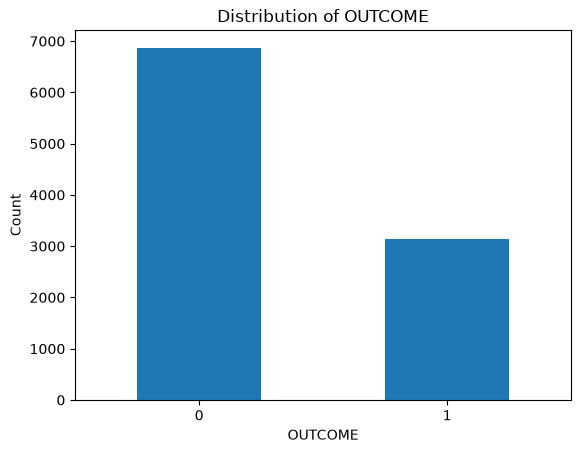

In [12]:
df["OUTCOME"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of OUTCOME")
plt.xlabel("OUTCOME")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

<div style="
    text-align: left;
    font-family: Arial, sans-serif;
    font-size: 16px;
    line-height: 1.8;
    color: #222222;
">

<p style="text-align: left;">
The column types, missing values, and target distribution were examined. The dataset contains both numerical and categorical variables. Only <code>CREDIT_SCORE</code> and <code>ANNUAL_MILEAGE</code> contain missing values. The target variable <code>OUTCOME</code> has only two values, 0 and 1, so it is a binary categorical variable. Its distribution is imbalanced because class 0 contains more observations than class 1.
</p>

</div>

<div style="
    font-family: Arial, sans-serif;
    text-align: left;
    color: #FF4F00;
    font-size: 24px;
    font-weight: bold;
">
3. Removing Outliers Using Boxplots and the IQR Method
</div>

In [13]:
outlier_columns = ["CREDIT_SCORE", "ANNUAL_MILEAGE"]

outlier_columns

['CREDIT_SCORE', 'ANNUAL_MILEAGE']

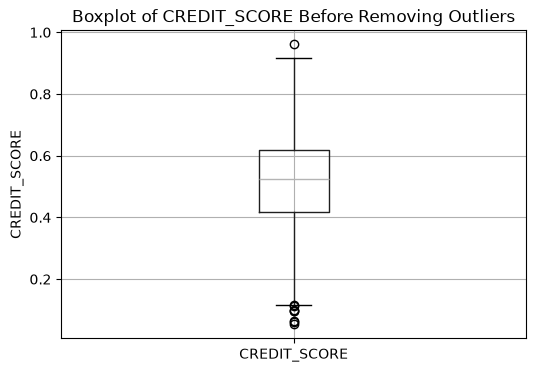

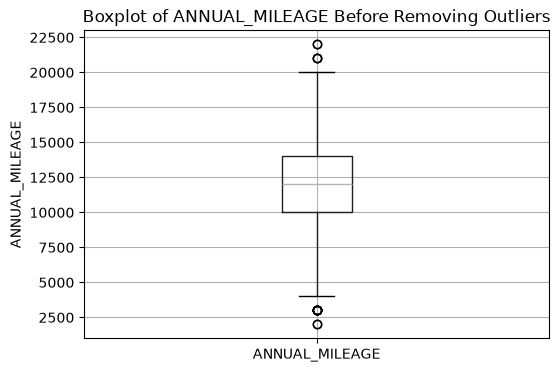

In [14]:
for col in outlier_columns:
    plt.figure(figsize=(6, 4))
    df.boxplot(column=col)
    plt.title(f"Boxplot of {col} Before Removing Outliers")
    plt.ylabel(col)
    plt.show()

In [15]:
outlier_summary = []

for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    
    outlier_summary.append({
        "column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,CREDIT_SCORE,0.417191,0.618312,0.20112,0.115511,0.919992,9
1,ANNUAL_MILEAGE,10000.000000,14000.000000,4000.00000,4000.000000,20000.000000,17


In [16]:
outlier_mask = pd.Series(True, index=df.index)

for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_mask = outlier_mask & (
        df[col].between(lower_bound, upper_bound) | df[col].isna()
    )

df_no_outliers = df[outlier_mask].copy()

print("Data shape before outlier removal:", df.shape)
print("Data shape after outlier removal:", df_no_outliers.shape)
print("Number of removed rows:", df.shape[0] - df_no_outliers.shape[0])

Data shape before outlier removal: (10000, 18)
Data shape after outlier removal: (9974, 18)
Number of removed rows: 26


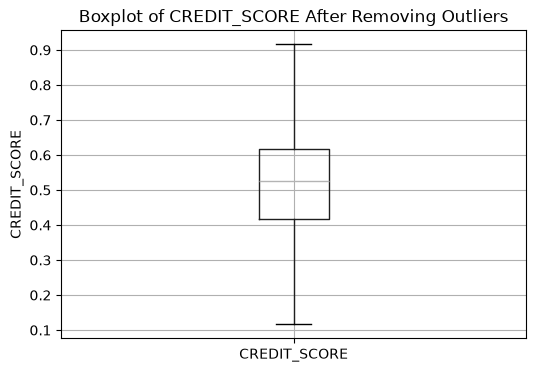

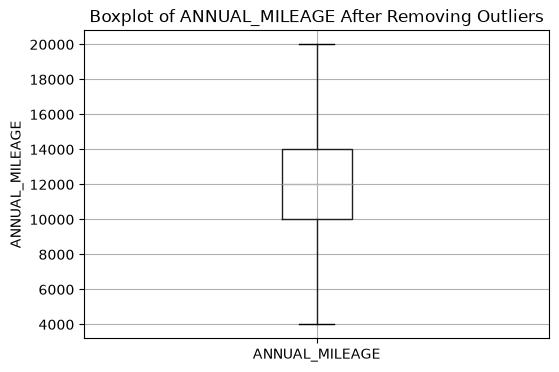

In [17]:
for col in outlier_columns:
    plt.figure(figsize=(6, 4))
    df_no_outliers.boxplot(column=col)
    plt.title(f"Boxplot of {col} After Removing Outliers")
    plt.ylabel(col)
    plt.show()

In [18]:
df = df_no_outliers.copy()

df.shape

(9974, 18)

<div style="
    text-align: left;
    font-family: Arial, sans-serif;
    font-size: 16px;
    line-height: 1.8;
    color: #222222;
">

<p style="text-align: left;">
Outliers were examined using the IQR method. Only continuous numerical variables such as <code>CREDIT_SCORE</code> and <code>ANNUAL_MILEAGE</code> were used for outlier removal. Other numerical columns, such as <code>POSTAL_CODE</code> and binary variables, are categorical in nature, so treating their extreme values as outliers would not be appropriate. After outlier removal, a small number of rows were excluded and the dataset was cleaner for the remaining analysis.
</p>

</div>

<div style="
    font-family: Arial, sans-serif;
    text-align: left;
    color: #FF4F00;
    font-size: 24px;
    font-weight: bold;
">
4. Comparing Numerical Variables Across OUTCOME Groups
</div>

In [19]:
comparison_columns = [
    "CREDIT_SCORE",
    "ANNUAL_MILEAGE",
    "SPEEDING_VIOLATIONS",
    "DUIS",
    "PAST_ACCIDENTS"
]

comparison_columns

['CREDIT_SCORE',
 'ANNUAL_MILEAGE',
 'SPEEDING_VIOLATIONS',
 'DUIS',
 'PAST_ACCIDENTS']

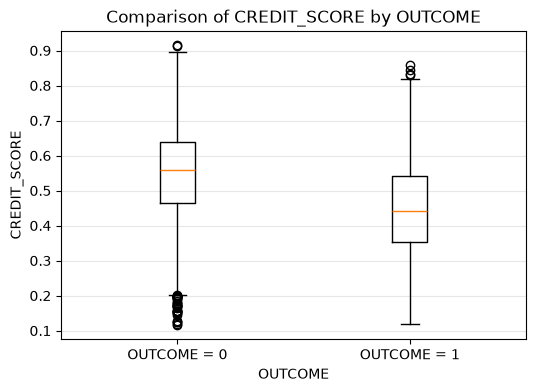

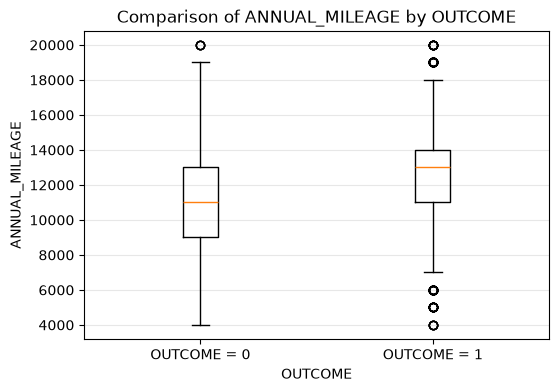

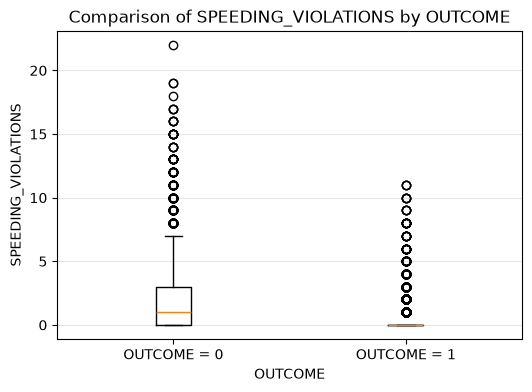

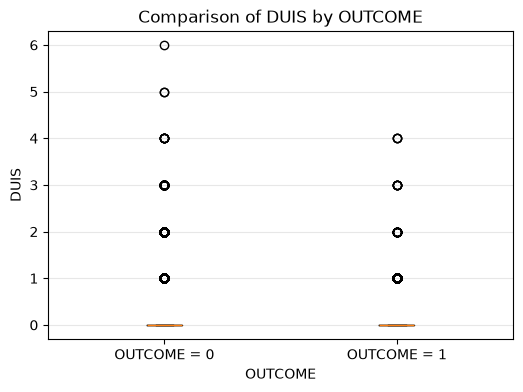

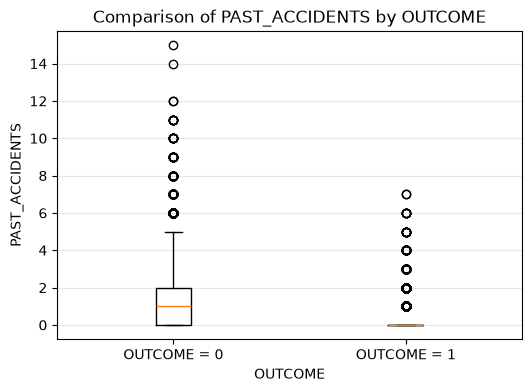

In [20]:
for col in comparison_columns:
    group_0 = df[df["OUTCOME"] == 0][col].dropna()
    group_1 = df[df["OUTCOME"] == 1][col].dropna()
    
    plt.figure(figsize=(6, 4))
    plt.boxplot(
        [group_0, group_1],
        tick_labels=["OUTCOME = 0", "OUTCOME = 1"]
    )
    plt.title(f"Comparison of {col} by OUTCOME")
    plt.xlabel("OUTCOME")
    plt.ylabel(col)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

In [21]:
comparison_table = pd.DataFrame({
    "mean_OUTCOME_0": df[df["OUTCOME"] == 0][comparison_columns].mean(),
    "median_OUTCOME_0": df[df["OUTCOME"] == 0][comparison_columns].median(),
    "mean_OUTCOME_1": df[df["OUTCOME"] == 1][comparison_columns].mean(),
    "median_OUTCOME_1": df[df["OUTCOME"] == 1][comparison_columns].median()
})

comparison_table.round(2)

,mean_OUTCOME_0,median_OUTCOME_0,mean_OUTCOME_1,median_OUTCOME_1
CREDIT_SCORE,0.55,0.56,0.45,0.44
ANNUAL_MILEAGE,11353.16,11000.00,12477.11,13000.00
SPEEDING_VIOLATIONS,1.92,1.00,0.52,0.00
DUIS,0.31,0.00,0.08,0.00
PAST_ACCIDENTS,1.40,1.00,0.29,0.00


<div style="
    text-align: left;
    font-family: Arial, sans-serif;
    font-size: 16px;
    line-height: 1.8;
    color: #222222;
">

<p style="text-align: left;">
Several important numerical variables were compared between the <code>OUTCOME = 0</code> and <code>OUTCOME = 1</code> groups. Policyholders in the <code>OUTCOME = 1</code> group generally had lower <code>CREDIT_SCORE</code> values and higher <code>ANNUAL_MILEAGE</code> values. This suggests that credit score and annual mileage may be associated with the likelihood of a recorded insurance claim.
</p>

</div>

<div style="
    font-family: Arial, sans-serif;
    text-align: left;
    color: #FF4F00;
    font-size: 24px;
    font-weight: bold;
">
5. Balancing the Target Variable
</div>

In [22]:
outcome_before_balance = pd.DataFrame({
    "count": df["OUTCOME"].value_counts().sort_index(),
    "percent": (df["OUTCOME"].value_counts(normalize=True).sort_index() * 100).round(2)
})

outcome_before_balance

,count,percent
OUTCOME,,
0,6855,68.73
1,3119,31.27


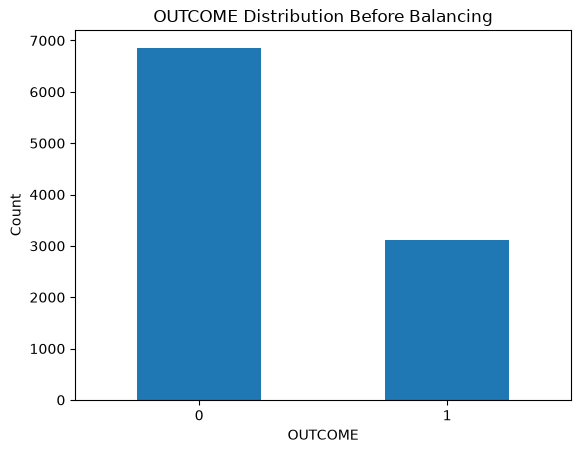

In [23]:
df["OUTCOME"].value_counts().sort_index().plot(kind="bar")

plt.title("OUTCOME Distribution Before Balancing")
plt.xlabel("OUTCOME")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [24]:
df_class_0 = df[df["OUTCOME"] == 0]
df_class_1 = df[df["OUTCOME"] == 1]

minority_count = min(len(df_class_0), len(df_class_1))

df_class_0_sampled = df_class_0.sample(n=minority_count, random_state=42)
df_class_1_sampled = df_class_1.sample(n=minority_count, random_state=42)

df_balanced = pd.concat([df_class_0_sampled, df_class_1_sampled], axis=0)

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("Data shape before balancing:", df.shape)
print("Data shape after balancing:", df_balanced.shape)

df_balanced["OUTCOME"].value_counts().sort_index()

Data shape before balancing: (9974, 18)
Data shape after balancing: (6238, 18)


OUTCOME
0    3119
1    3119
Name: count, dtype: int64

In [25]:
outcome_after_balance = pd.DataFrame({
    "count": df_balanced["OUTCOME"].value_counts().sort_index(),
    "percent": (df_balanced["OUTCOME"].value_counts(normalize=True).sort_index() * 100).round(2)
})

outcome_after_balance

,count,percent
OUTCOME,,
0,3119,50.0
1,3119,50.0


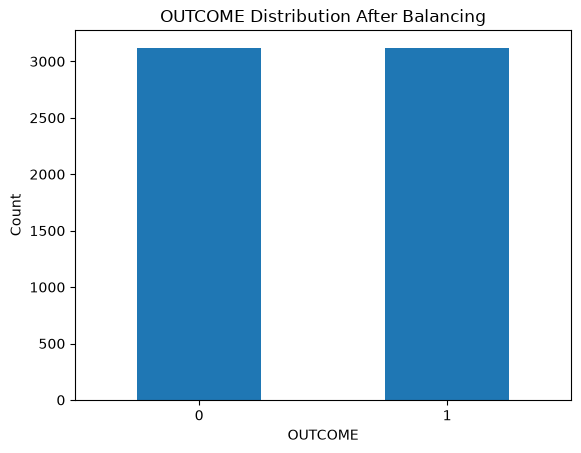

In [26]:
df_balanced["OUTCOME"].value_counts().sort_index().plot(kind="bar")

plt.title("OUTCOME Distribution After Balancing")
plt.xlabel("OUTCOME")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [27]:
df = df_balanced.copy()

df.shape

(6238, 18)

<div style="
    text-align: left;
    font-family: Arial, sans-serif;
    font-size: 16px;
    line-height: 1.8;
    color: #222222;
">

<p style="text-align: left;">
The target imbalance was addressed using random undersampling. Because class 0 contained more observations than class 1, the majority class was sampled down to the size of the minority class. After balancing, both classes contained the same number of observations, creating a more balanced dataset for model training.
</p>

</div>

<div style="
    font-family: Arial, sans-serif;
    text-align: left;
    color: #FF4F00;
    font-size: 24px;
    font-weight: bold;
">
6. Encoding Categorical Variables with One-Hot Encoding
</div>

In [28]:
categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Categorical columns:")
categorical_columns

Categorical columns:


['AGE',
 'GENDER',
 'RACE',
 'DRIVING_EXPERIENCE',
 'EDUCATION',
 'INCOME',
 'VEHICLE_YEAR',
 'VEHICLE_TYPE']

In [29]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=False,
    dtype=int
)

print("Data shape before One-Hot Encoding:", df.shape)
print("Data shape after One-Hot Encoding:", df_encoded.shape)

df_encoded.head()

Data shape before One-Hot Encoding: (6238, 18)
Data shape after One-Hot Encoding: (6238, 33)


,CREDIT_SCORE,VEHICLE_OWNERSHIP,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME,...,EDUCATION_none,EDUCATION_university,INCOME_middle class,INCOME_poverty,INCOME_upper class,INCOME_working class,VEHICLE_YEAR_after 2015,VEHICLE_YEAR_before 2015,VEHICLE_TYPE_sedan,VEHICLE_TYPE_sports car
0,0.590765,1,0,1,10238,NaN,0,0,1,0,...,0,1,1,0,0,0,1,0,1,0
1,0.118445,0,0,1,10238,17000.0,1,1,0,0,...,1,0,0,1,0,0,0,1,1,0
2,0.507636,0,1,1,32765,7000.0,6,0,0,0,...,1,0,0,1,0,0,0,1,1,0
3,NaN,0,0,1,32765,8000.0,2,0,0,1,...,0,1,1,0,0,0,0,1,0,1
4,0.306241,0,0,0,10238,NaN,0,0,0,1,...,0,1,0,1,0,0,0,1,1,0


In [30]:
df_encoded.columns.tolist()

['CREDIT_SCORE',
 'VEHICLE_OWNERSHIP',
 'MARRIED',
 'CHILDREN',
 'POSTAL_CODE',
 'ANNUAL_MILEAGE',
 'SPEEDING_VIOLATIONS',
 'DUIS',
 'PAST_ACCIDENTS',
 'OUTCOME',
 'AGE_16-25',
 'AGE_26-39',
 'AGE_40-64',
 'AGE_65+',
 'GENDER_female',
 'GENDER_male',
 'RACE_majority',
 'RACE_minority',
 'DRIVING_EXPERIENCE_0-9y',
 'DRIVING_EXPERIENCE_10-19y',
 'DRIVING_EXPERIENCE_20-29y',
 'DRIVING_EXPERIENCE_30y+',
 'EDUCATION_high school',
 'EDUCATION_none',
 'EDUCATION_university',
 'INCOME_middle class',
 'INCOME_poverty',
 'INCOME_upper class',
 'INCOME_working class',
 'VEHICLE_YEAR_after 2015',
 'VEHICLE_YEAR_before 2015',
 'VEHICLE_TYPE_sedan',
 'VEHICLE_TYPE_sports car']

In [31]:
remaining_categorical_columns = df_encoded.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Remaining categorical columns:")
remaining_categorical_columns

Remaining categorical columns:


[]

In [32]:
df = df_encoded.copy()

df.shape

(6238, 33)

<div style="
    text-align: left;
    font-family: Arial, sans-serif;
    font-size: 16px;
    line-height: 1.8;
    color: #222222;
">

<p style="text-align: left;">
The categorical columns were converted into numerical variables using One-Hot Encoding. Machine-learning models cannot directly process text categories, so each category was represented by a separate binary column. After this transformation, no non-numerical columns remained in the dataset.
</p>

</div>

<div style="
    font-family: Arial, sans-serif;
    text-align: left;
    color: #FF4F00;
    font-size: 24px;
    font-weight: bold;
">
7. Splitting the Data into Training and Test Sets
</div>

In [33]:
X = df.drop(columns=["OUTCOME"])
y = df["OUTCOME"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (6238, 32)
Target vector shape: (6238,)


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4990, 32)
X_test shape: (1248, 32)
y_train shape: (4990,)
y_test shape: (1248,)


In [35]:
train_balance = pd.DataFrame({
    "count": y_train.value_counts().sort_index(),
    "percent": (y_train.value_counts(normalize=True).sort_index() * 100).round(2)
})

test_balance = pd.DataFrame({
    "count": y_test.value_counts().sort_index(),
    "percent": (y_test.value_counts(normalize=True).sort_index() * 100).round(2)
})

print("Class distribution in the training set:")
display(train_balance)

print("Class distribution in the test set:")
display(test_balance)

Class distribution in the training set:


,count,percent
OUTCOME,,
0,2495,50.0
1,2495,50.0


Class distribution in the test set:


,count,percent
OUTCOME,,
0,624,50.0
1,624,50.0


In [36]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Missing values in X_train:", X_train.isna().sum().sum())
print("Missing values in X_test:", X_test.isna().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


In [37]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("Does X_train contain missing values?", X_train.isna().sum().sum() > 0)
print("Does X_test contain missing values?", X_test.isna().sum().sum() > 0)

X_train shape: (4990, 32)
X_test shape: (1248, 32)
y_train shape: (4990,)
y_test shape: (1248,)
Does X_train contain missing values? False
Does X_test contain missing values? False


<div style="
    text-align: left;
    font-family: Arial, sans-serif;
    font-size: 16px;
    line-height: 1.8;
    color: #222222;
">

<p style="text-align: left;">
The data was divided into features and the target variable. <code>OUTCOME</code> was used as the target, while the remaining columns were used as model inputs. An 80/20 train-test split was applied. Missing values were filled with the median, and the imputer was fitted only on the training data to prevent information leakage from the test set.
</p>

</div>

<div style="
    font-family: Arial, sans-serif;
    text-align: left;
    color: #FF4F00;
    font-size: 24px;
    font-weight: bold;
">
8. Classification with Decision Tree and Linear SVM
</div>

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [39]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree accuracy:", round(dt_accuracy, 4))

Decision Tree accuracy: 0.7588


In [40]:
dt_confusion_matrix = confusion_matrix(y_test, y_pred_dt)

dt_confusion_df = pd.DataFrame(
    dt_confusion_matrix,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

dt_confusion_df

,Predicted 0,Predicted 1
Actual 0,493,131
Actual 1,170,454


In [41]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.74      0.79      0.77       624
           1       0.78      0.73      0.75       624

    accuracy                           0.76      1248
   macro avg       0.76      0.76      0.76      1248
weighted avg       0.76      0.76      0.76      1248



In [42]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
svm_model = LinearSVC(
    random_state=42,
    max_iter=10000
)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("Linear SVM accuracy:", round(svm_accuracy, 4))

Linear SVM accuracy: 0.8141


In [44]:
svm_confusion_matrix = confusion_matrix(y_test, y_pred_svm)

svm_confusion_df = pd.DataFrame(
    svm_confusion_matrix,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

svm_confusion_df

,Predicted 0,Predicted 1
Actual 0,499,125
Actual 1,107,517


In [45]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81       624
           1       0.81      0.83      0.82       624

    accuracy                           0.81      1248
   macro avg       0.81      0.81      0.81      1248
weighted avg       0.81      0.81      0.81      1248



In [46]:
model_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Linear SVM"],
    "Accuracy": [dt_accuracy, svm_accuracy]
})

model_comparison["Accuracy"] = model_comparison["Accuracy"].round(4)

model_comparison

,Model,Accuracy
0,Decision Tree,0.7588
1,Linear SVM,0.8141


In [47]:
print("Decision Tree confusion matrix:")
display(dt_confusion_df)

print("Linear SVM confusion matrix:")
display(svm_confusion_df)

Decision Tree confusion matrix:


,Predicted 0,Predicted 1
Actual 0,493,131
Actual 1,170,454


Linear SVM confusion matrix:


,Predicted 0,Predicted 1
Actual 0,499,125
Actual 1,107,517


In [48]:
dt_correct = (y_test == y_pred_dt).sum()
dt_wrong = (y_test != y_pred_dt).sum()

svm_correct = (y_test == y_pred_svm).sum()
svm_wrong = (y_test != y_pred_svm).sum()

error_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Linear SVM"],
    "Correct Predictions": [dt_correct, svm_correct],
    "Wrong Predictions": [dt_wrong, svm_wrong],
    "Accuracy": [dt_accuracy, svm_accuracy]
})

error_comparison["Accuracy"] = error_comparison["Accuracy"].round(4)

error_comparison

,Model,Correct Predictions,Wrong Predictions,Accuracy
0,Decision Tree,947,301,0.7588
1,Linear SVM,1016,232,0.8141


<div style="
    text-align: left;
    font-family: Arial, sans-serif;
    font-size: 16px;
    line-height: 1.8;
    color: #222222;
">

<p style="text-align: left;">
A Decision Tree and a Linear SVM classifier were trained and evaluated on the test set. The Decision Tree did not require feature scaling, while the SVM inputs were standardized because SVM models are sensitive to differences in feature scale. In this analysis, the Linear SVM achieved higher test accuracy than the Decision Tree.
</p>

</div>

<div style="
    font-family: Arial, sans-serif;
    text-align: left;
    color: #FF4F00;
    font-size: 24px;
    font-weight: bold;
">
9. Feature Importance in the Decision Tree Model
</div>

In [49]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,DRIVING_EXPERIENCE_0-9y,0.269848
1,CREDIT_SCORE,0.174090
2,VEHICLE_OWNERSHIP,0.087745
3,ANNUAL_MILEAGE,0.074764
4,POSTAL_CODE,0.065926
5,DRIVING_EXPERIENCE_10-19y,0.052284
6,VEHICLE_YEAR_before 2015,0.046704
7,PAST_ACCIDENTS,0.021242
8,SPEEDING_VIOLATIONS,0.019290
9,MARRIED,0.018134


In [50]:
top_10_features = feature_importance.head(10)

top_10_features

,Feature,Importance
0,DRIVING_EXPERIENCE_0-9y,0.269848
1,CREDIT_SCORE,0.174090
2,VEHICLE_OWNERSHIP,0.087745
3,ANNUAL_MILEAGE,0.074764
4,POSTAL_CODE,0.065926
5,DRIVING_EXPERIENCE_10-19y,0.052284
6,VEHICLE_YEAR_before 2015,0.046704
7,PAST_ACCIDENTS,0.021242
8,SPEEDING_VIOLATIONS,0.019290
9,MARRIED,0.018134


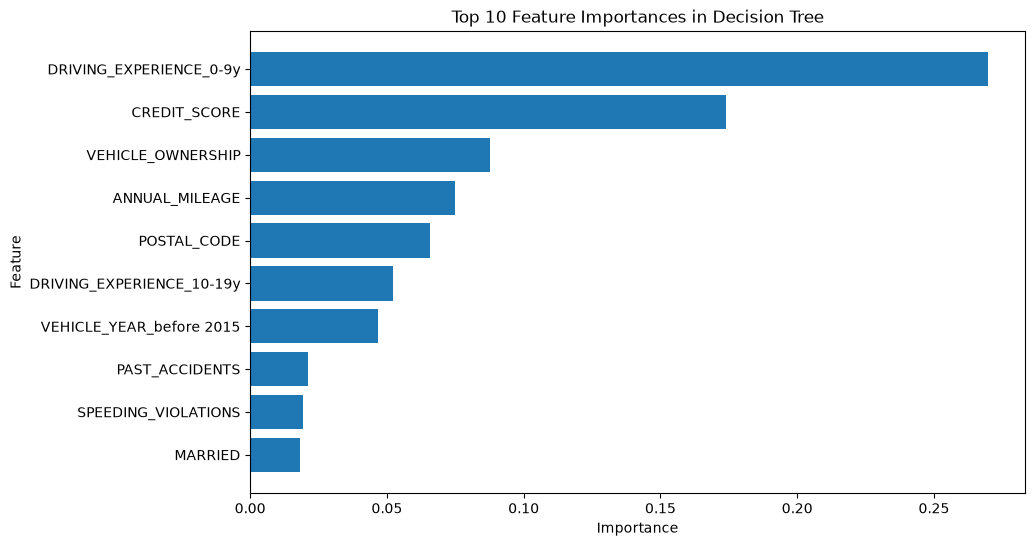

In [51]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_features["Feature"],
    top_10_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances in Decision Tree")
plt.gca().invert_yaxis()
plt.show()

In [52]:
original_categorical_columns = [
    "AGE",
    "GENDER",
    "RACE",
    "DRIVING_EXPERIENCE",
    "EDUCATION",
    "INCOME",
    "VEHICLE_YEAR",
    "VEHICLE_TYPE"
]

def get_original_feature_name(feature_name):
    for original_col in original_categorical_columns:
        if feature_name.startswith(original_col + "_"):
            return original_col
    return feature_name

feature_importance["Original_Feature"] = feature_importance["Feature"].apply(
    get_original_feature_name
)

grouped_feature_importance = (
    feature_importance
    .groupby("Original_Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

grouped_feature_importance

,Original_Feature,Importance
0,DRIVING_EXPERIENCE,0.323336
1,CREDIT_SCORE,0.174090
2,VEHICLE_OWNERSHIP,0.087745
3,ANNUAL_MILEAGE,0.074764
4,POSTAL_CODE,0.065926
5,VEHICLE_YEAR,0.061550
6,EDUCATION,0.031373
7,INCOME,0.030366
8,AGE,0.028262
9,GENDER,0.022972


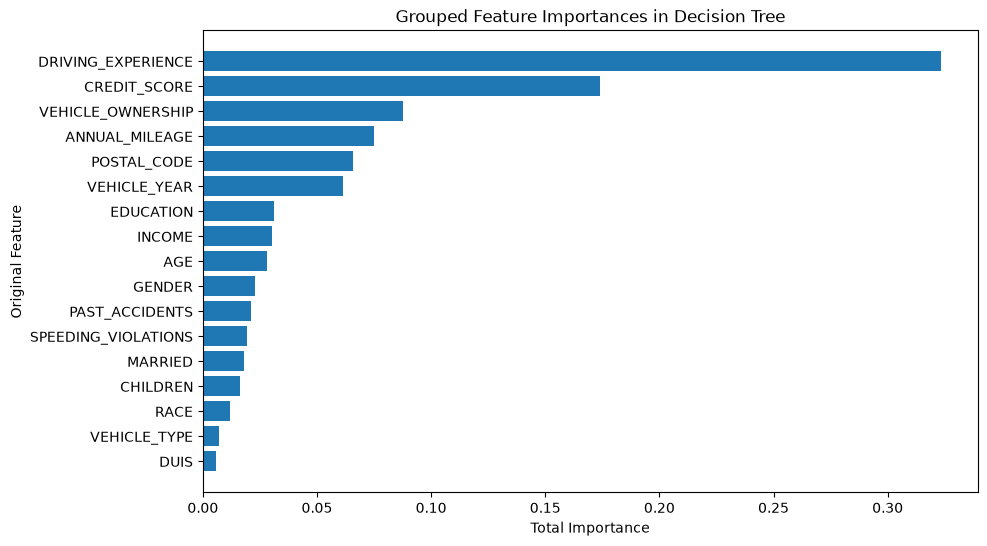

In [53]:
plt.figure(figsize=(10, 6))

plt.barh(
    grouped_feature_importance["Original_Feature"],
    grouped_feature_importance["Importance"]
)

plt.xlabel("Total Importance")
plt.ylabel("Original Feature")
plt.title("Grouped Feature Importances in Decision Tree")
plt.gca().invert_yaxis()
plt.show()

In [54]:
top_5_original_features = grouped_feature_importance.head(5)

top_5_original_features

,Original_Feature,Importance
0,DRIVING_EXPERIENCE,0.323336
1,CREDIT_SCORE,0.174090
2,VEHICLE_OWNERSHIP,0.087745
3,ANNUAL_MILEAGE,0.074764
4,POSTAL_CODE,0.065926


<div style="
    text-align: left;
    font-family: Arial, sans-serif;
    font-size: 16px;
    line-height: 1.8;
    color: #222222;
">

<p style="text-align: left;">
Feature importance was examined using the Decision Tree model. Because some categorical variables were expanded into several One-Hot encoded columns, the importance values of related dummy variables were grouped back under their original feature names. The results indicated that driving experience, credit score, vehicle ownership, and annual mileage were among the most influential variables.
</p>

</div>

<div style="
    font-family: Arial, sans-serif;
    text-align: left;
    color: #FF4F00;
    font-size: 24px;
    font-weight: bold;
">
10. Tuning the SVM Model with GridSearchCV
</div>

In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [56]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(random_state=42))
])

svm_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3


In [57]:
param_grid = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.1, 1, 10]
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1, 10],
        "svm__gamma": ["scale", 0.01, 0.1]
    }
]

param_grid

[{'svm__kernel': ['linear'], 'svm__C': [0.1, 1, 10]},
 {'svm__kernel': ['rbf'],
  'svm__C': [0.1, 1, 10],
  'svm__gamma': ['scale', 0.01, 0.1]}]

In [58]:
grid_search_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search_svm.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'svm__C': [0.1, 1, ...], 'svm__kernel': ['linear']}, {'svm__C': [0.1, 1, ...], 'svm__gamma': ['scale', 0.01, ...], 'svm__kernel': ['rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :r

In [59]:
print("Best SVM parameters:")
print(grid_search_svm.best_params_)

print("Best mean cross-validation accuracy:")
print(round(grid_search_svm.best_score_, 4))

Best SVM parameters:
{'svm__C': 0.1, 'svm__kernel': 'linear'}
Best mean cross-validation accuracy:
0.8289


In [60]:
best_svm_model = grid_search_svm.best_estimator_

y_pred_best_svm = best_svm_model.predict(X_test)

best_svm_accuracy = accuracy_score(y_test, y_pred_best_svm)

print("Best SVM test accuracy:", round(best_svm_accuracy, 4))

Best SVM test accuracy: 0.8069


In [61]:
best_svm_confusion_matrix = confusion_matrix(y_test, y_pred_best_svm)

best_svm_confusion_df = pd.DataFrame(
    best_svm_confusion_matrix,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

best_svm_confusion_df

,Predicted 0,Predicted 1
Actual 0,496,128
Actual 1,113,511


In [62]:
print(classification_report(y_test, y_pred_best_svm))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80       624
           1       0.80      0.82      0.81       624

    accuracy                           0.81      1248
   macro avg       0.81      0.81      0.81      1248
weighted avg       0.81      0.81      0.81      1248



In [63]:
grid_results = pd.DataFrame(grid_search_svm.cv_results_)

grid_results_summary = grid_results[
    [
        "param_svm__kernel",
        "param_svm__C",
        "param_svm__gamma",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

grid_results_summary.head(10)

,param_svm__kernel,param_svm__C,param_svm__gamma,mean_test_score,std_test_score,rank_test_score
0,linear,0.1,NaN,0.828856,0.007874,1
6,rbf,1.0,scale,0.828655,0.006466,2
2,linear,10.0,NaN,0.828655,0.007602,3
1,linear,1.0,NaN,0.828655,0.007602,3
7,rbf,1.0,0.01,0.828054,0.006177,5
10,rbf,10.0,0.01,0.825650,0.004727,6
4,rbf,0.1,0.01,0.822445,0.001393,7
3,rbf,0.1,scale,0.820241,0.002110,8
8,rbf,1.0,0.1,0.814028,0.002861,9
9,rbf,10.0,scale,0.805611,0.004148,10


In [64]:
svm_tuning_comparison = pd.DataFrame({
    "Model": ["Initial Linear SVM", "Best SVM with GridSearch"],
    "Accuracy": [svm_accuracy, best_svm_accuracy]
})

svm_tuning_comparison["Accuracy"] = svm_tuning_comparison["Accuracy"].round(4)

svm_tuning_comparison

,Model,Accuracy
0,Initial Linear SVM,0.8141
1,Best SVM with GridSearch,0.8069


<div style="
    text-align: left;
    font-family: Arial, sans-serif;
    font-size: 16px;
    line-height: 1.8;
    color: #222222;
">

<p style="text-align: left;">
Several SVM parameter combinations were evaluated to identify the best configuration. GridSearchCV selected the best model based on cross-validation performance, and the selected model was then evaluated on the test set. A slightly lower test accuracy than the initial Linear SVM is not necessarily a problem, because the best average cross-validation result does not always produce the highest score on a single test split.
</p>

</div>

<div style="
    font-family: Arial, sans-serif;
    text-align: center;
    color: #0095DA;
    font-size: 28px;
    font-weight: bold;
">
............................................. Supplementary Analysis .............................................
</div>

<div style="
    font-family: Arial, sans-serif;
    text-align: left;
    color: #FF4F00;
    font-size: 24px;
    font-weight: bold;
">
11. Comparison with a Baseline Model
</div>

In [65]:
from sklearn.dummy import DummyClassifier

In [66]:
dummy_model = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

dummy_model.fit(X_train, y_train)

y_pred_dummy = dummy_model.predict(X_test)

dummy_accuracy = accuracy_score(y_test, y_pred_dummy)

print("Baseline model accuracy:", round(dummy_accuracy, 4))

Baseline model accuracy: 0.5


In [67]:
baseline_comparison = pd.DataFrame({
    "Model": [
        "Dummy Baseline",
        "Decision Tree",
        "Linear SVM",
        "Best SVM with GridSearch"
    ],
    "Accuracy": [
        dummy_accuracy,
        dt_accuracy,
        svm_accuracy,
        best_svm_accuracy
    ]
})

baseline_comparison["Accuracy"] = baseline_comparison["Accuracy"].round(4)

baseline_comparison

,Model,Accuracy
0,Dummy Baseline,0.5000
1,Decision Tree,0.7588
2,Linear SVM,0.8141
3,Best SVM with GridSearch,0.8069


<div style="
    text-align: left;
    font-family: Arial, sans-serif;
    font-size: 16px;
    line-height: 1.8;
    color: #222222;
">

<p style="text-align: left;">
A baseline classifier was created to compare the trained models with a simple reference point. The baseline always predicts the most frequent class and does not learn complex relationships from the data. Both the Decision Tree and SVM models performed better than the baseline, indicating that they learned meaningful patterns from the dataset.
</p>

</div>

<div style="
    font-family: Arial, sans-serif;
    text-align: left;
    color: #FF4F00;
    font-size: 24px;
    font-weight: bold;
">
12. Claim Rate by Driving Experience
</div>

In [68]:
experience_order = ["0-9y", "10-19y", "20-29y", "30y+"]

df_claim_rate = df_no_outliers.copy()

df_claim_rate["DRIVING_EXPERIENCE"] = pd.Categorical(
    df_claim_rate["DRIVING_EXPERIENCE"],
    categories=experience_order,
    ordered=True
)

driving_experience_claim_rate = (
    df_claim_rate
    .groupby("DRIVING_EXPERIENCE", observed=False)["OUTCOME"]
    .agg(["count", "mean"])
    .reset_index()
)

driving_experience_claim_rate["claim_rate_percent"] = (
    driving_experience_claim_rate["mean"] * 100
).round(2)

driving_experience_claim_rate

,DRIVING_EXPERIENCE,count,mean,claim_rate_percent
0,0-9y,3517,0.627523,62.75
1,10-19y,3293,0.238081,23.81
2,20-29y,2115,0.051064,5.11
3,30y+,1049,0.019066,1.91


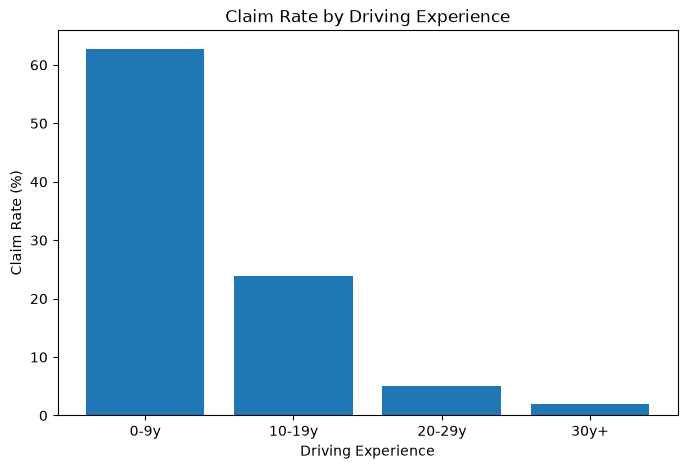

In [69]:
plt.figure(figsize=(8, 5))

plt.bar(
    driving_experience_claim_rate["DRIVING_EXPERIENCE"].astype(str),
    driving_experience_claim_rate["claim_rate_percent"]
)

plt.xlabel("Driving Experience")
plt.ylabel("Claim Rate (%)")
plt.title("Claim Rate by Driving Experience")
plt.xticks(rotation=0)
plt.show()

<div style="
    text-align: left;
    font-family: Arial, sans-serif;
    font-size: 16px;
    line-height: 1.8;
    color: #222222;
">

<p style="text-align: left;">
Claim rates were compared across driving-experience groups. This analysis used the cleaned dataset before class balancing so the reported rates would remain closer to the original distribution. Policyholders with less driving experience had substantially higher claim rates, supporting the importance of <code>DRIVING_EXPERIENCE</code> as an informative feature in this project.
</p>

</div>

<div style="
    font-family: Arial, sans-serif;
    text-align: left;
    color: #FF4F00;
    font-size: 30px;
    font-weight: bold;
">
Conclusion
</div>

<div style="
    text-align: left;
    font-family: Arial, sans-serif;
    font-size: 16px;
    line-height: 1.8;
    color: #222222;
">

<p style="text-align: left;">
This project examined a car insurance dataset from initial exploration through preprocessing, modeling, and evaluation. The identifier column was removed, missing values and class imbalance were reviewed, and outliers in <code>CREDIT_SCORE</code> and <code>ANNUAL_MILEAGE</code> were handled using the IQR method. Categorical variables were transformed with One-Hot Encoding, and the data was prepared for machine learning.

Two classification models were trained. The Linear SVM achieved an accuracy of 0.8141, outperforming the Decision Tree, which reached 0.7588. GridSearchCV was then used to tune the SVM model, but the tuned model achieved a slightly lower test accuracy of 0.8069. Therefore, the initial Linear SVM produced the strongest test-set performance in this analysis.

The feature-importance results showed that <code>DRIVING_EXPERIENCE</code>, <code>CREDIT_SCORE</code>, <code>VEHICLE_OWNERSHIP</code>, <code>ANNUAL_MILEAGE</code>, and <code>POSTAL_CODE</code> were among the most influential variables in the Decision Tree. The supplementary claim-rate analysis also showed that policyholders with less driving experience had much higher claim rates.

Overall, the trained models performed better than the baseline classifier and captured useful patterns in the data. The Linear SVM is the preferred option when predictive accuracy is the main objective, while the Decision Tree remains useful when interpretability and feature importance are priorities.
</p>

</div>

<div style="
    font-family: Arial, sans-serif;
    text-align: center;
    color: #0095DA;
    font-size: 28px;
    font-weight: bold;
">
....................................................... Thank You .......................................................
</div>